In [1]:
import pickle
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
with open(f'./results/raw_times.pkl', 'rb') as f:
            raw_times = pickle.load(f)

## Summary

In [3]:
raw_df = pd.DataFrame.from_dict(raw_times)
raw_df.describe()

,motifs obj,shortest paths obj,shortest distances,Average Degree for Nearest Neighbors (Undirected),Clustering Coefficient,Rich Club Coefficient,Average Local Efficiency,Average Shortest Path Length,Betweenness Centrality,Center,...,Max Out-Degree,Number of Arcs,Out-Degree,Regulators,Self Regulations,Gene % in the Giant Component,Undirected Density,get_props,edges,nodes
count,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,...,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000
mean,0.755048,0.048063,0.194458,0.011399,1.165346,0.177181,29.626724,0.000479,0.159502,0.053960,...,0.000040,0.000720,0.000240,0.000160,0.001800,0.003400,0.000600,61.512906,22970.400000,574.440000
std,0.316202,0.011213,0.027326,0.003027,0.409401,0.048622,10.353892,0.000509,0.029647,0.008207,...,0.000200,0.000458,0.000436,0.000375,0.000409,0.000646,0.000500,22.608720,5084.830864,7.211565
min,0.366001,0.025995,0.145996,0.005998,0.577999,0.110003,13.484691,0.000000,0.119002,0.035992,...,0.000000,0.000000,0.000000,0.000000,0.000997,0.002000,0.000000,27.873387,15392.000000,555.000000
25%,0.601998,0.042518,0.179037,0.009998,0.948036,0.142004,23.901551,0.000000,0.135996,0.048006,...,0.000000,0.000000,0.000000,0.000000,0.001999,0.003000,0.000000,49.355046,20363.000000,569.000000
50%,0.669988,0.047000,0.189996,0.011994,1.095999,0.167004,28.293468,0.000000,0.152668,0.053995,...,0.000000,0.000999,0.000000,0.000000,0.002000,0.003001,0.000999,56.820406,22119.000000,575.000000
75%,0.930997,0.054000,0.204999,0.013002,1.370526,0.206996,35.867072,0.001000,0.171998,0.061996,...,0.000000,0.001000,0.000000,0.000000,0.002000,0.003999,0.001000,73.592162,27014.000000,581.000000
max,1.687032,0.070999,0.257000,0.018002,2.222525,0.299528,57.840295,0.001003,0.233995,0.066999,...,0.001001,0.001001,0.001000,0.001003,0.002002,0.005003,0.001001,127.347540,36448.000000,583.000000


## Overall times

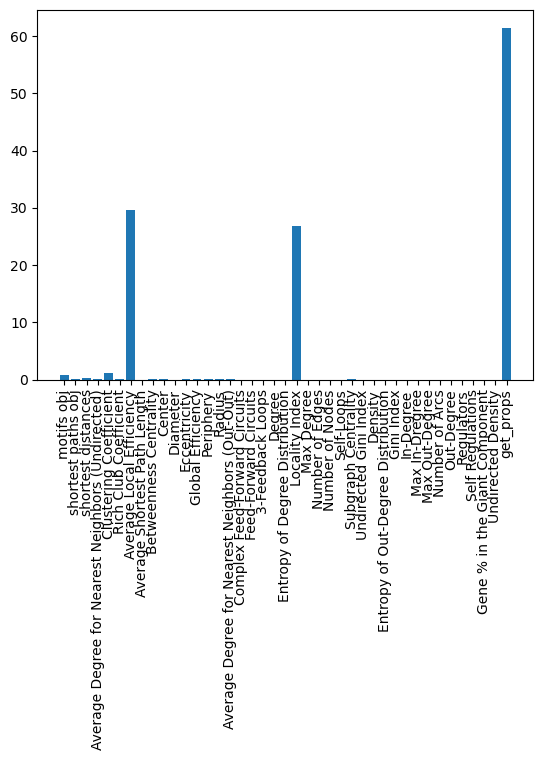

In [4]:
raw_means = {}

for prop, times in raw_times.items():
    if prop != 'edges' and prop != 'nodes':
        raw_means[prop] = np.asarray(times).mean()

names = list(raw_means.keys())
values = list(raw_means.values())

plt.bar(range(len(raw_means)), values, tick_label=names, align='center')
plt.xticks(rotation = 90)
plt.show()

## Relationship between number of edges and computing times

In [5]:
final_df = pd.DataFrame()
for i,(prop, times) in enumerate(raw_times.items()):
    if prop != 'edges' and prop != 'nodes':
        df = pd.DataFrame({'Process': prop, 'Edges': raw_df['edges'], 'Time (s)': times})
        final_df = pd.concat([final_df, df])

final_df

,Process,Edges,Time (s)
0,motifs obj,18299,0.569997
1,motifs obj,20363,0.640033
2,motifs obj,21445,0.646035
3,motifs obj,22119,0.669988
4,motifs obj,22301,0.712001
...,...,...,...
20,get_props,20415,56.820406
21,get_props,23623,70.472540
22,get_props,24982,65.239657
23,get_props,27245,73.592162


c:\Users\PepeS\miniconda3\envs\netective\lib\site-packages\seaborn\regression.py:582: UserWarning: sharey is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


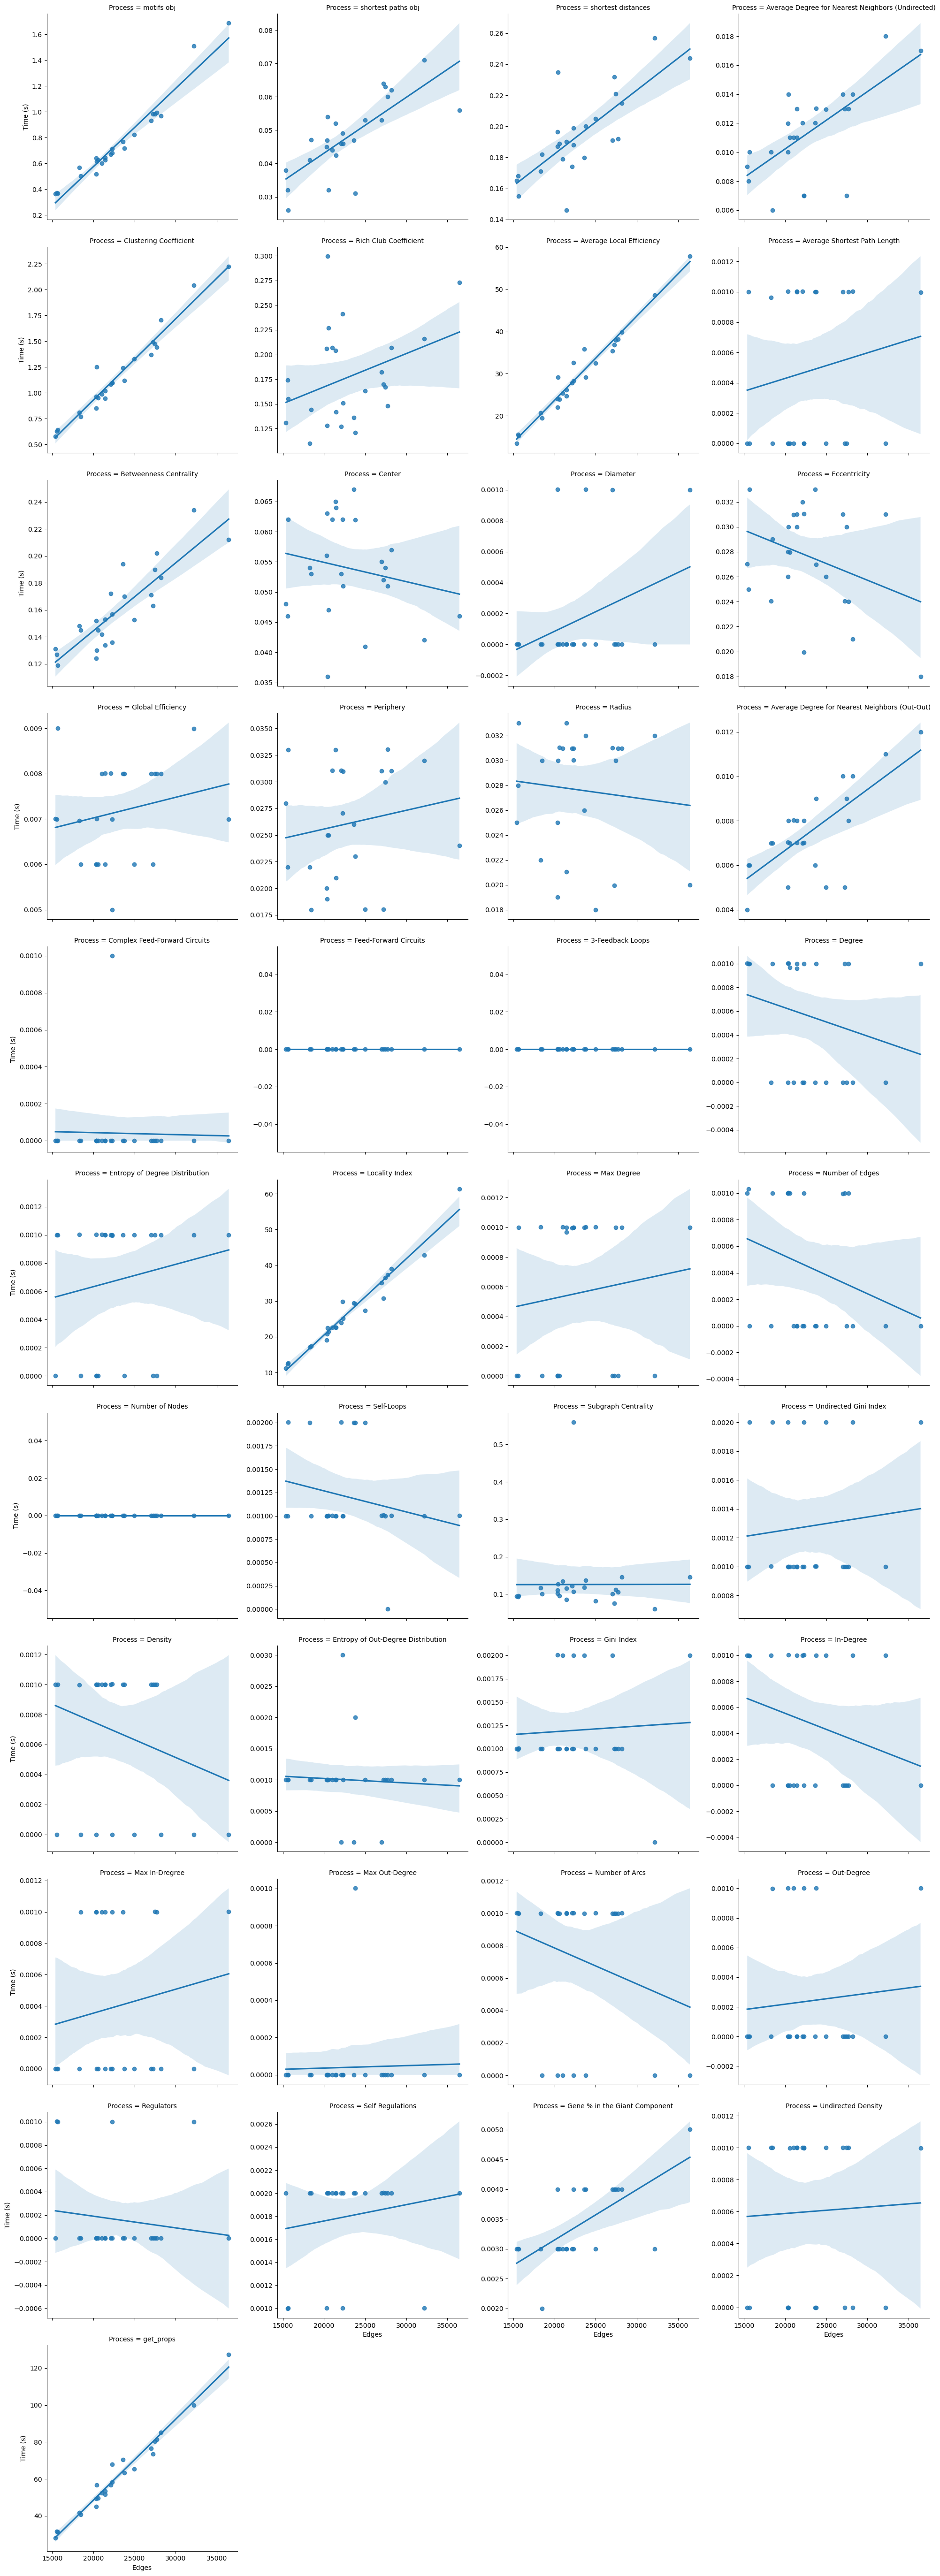

In [6]:
sns.lmplot(x='Edges', y='Time (s)', data=final_df, col='Process', height= 5, aspect= 1, sharey=False, col_wrap=4)

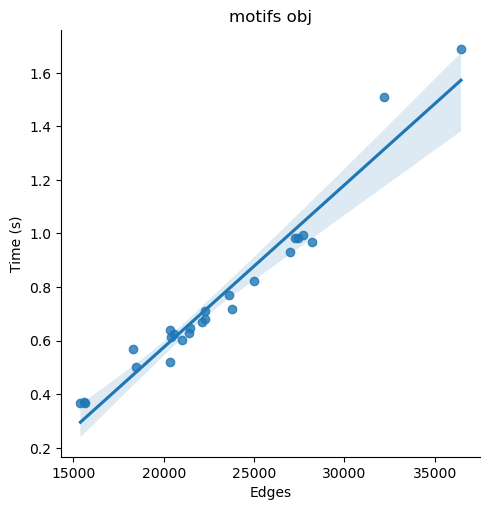

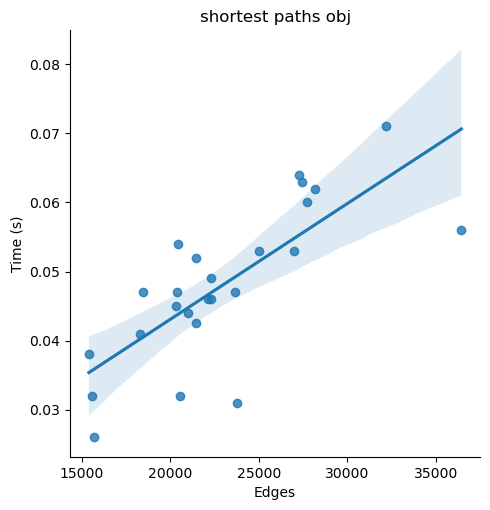

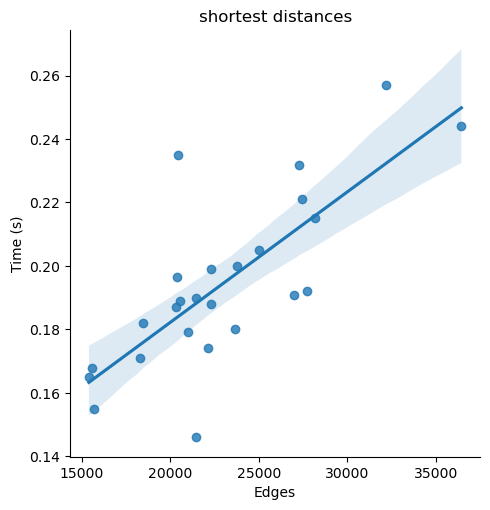

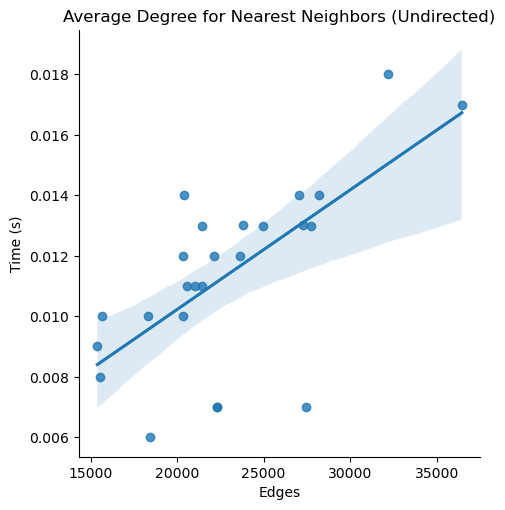

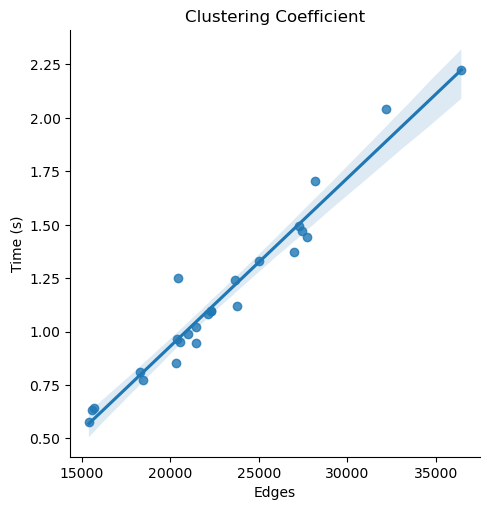

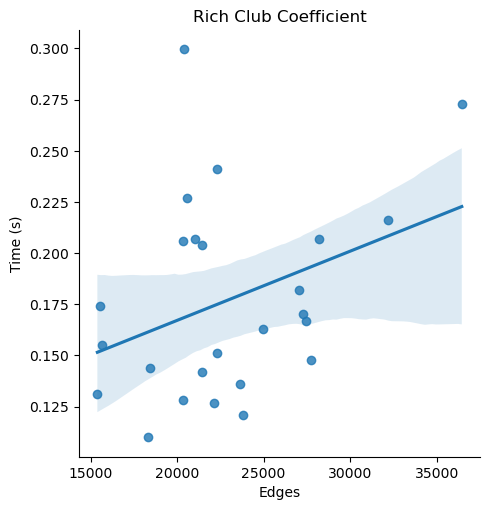

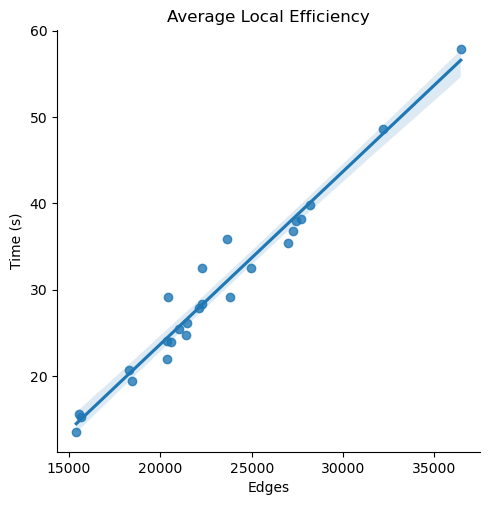

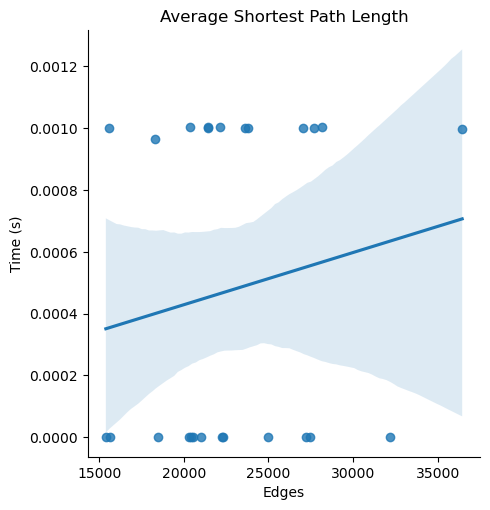

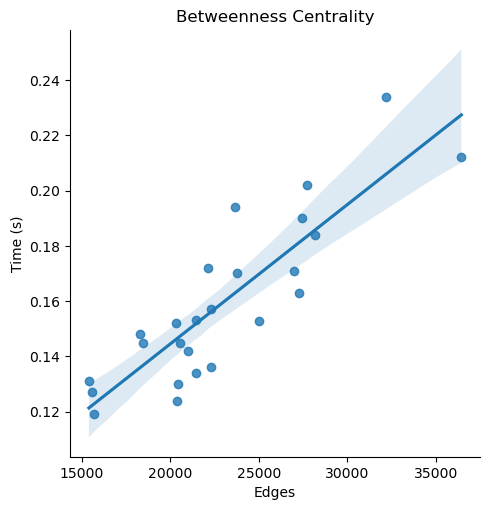

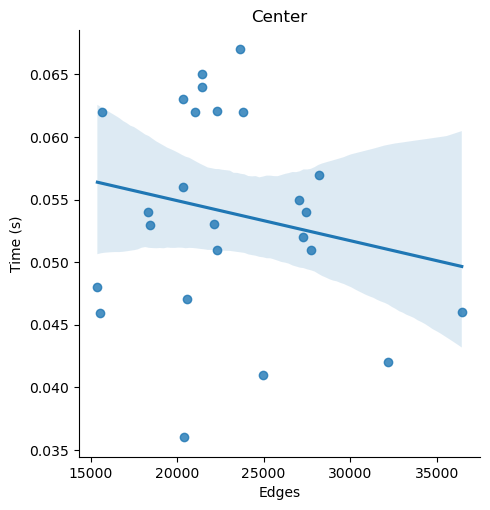

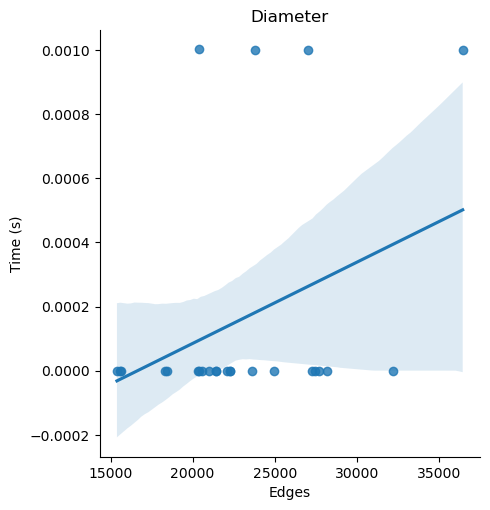

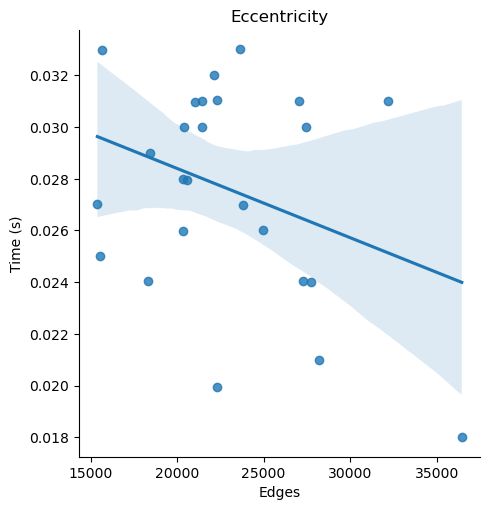

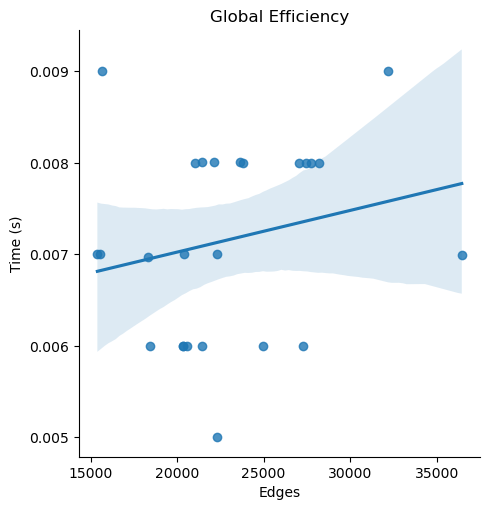

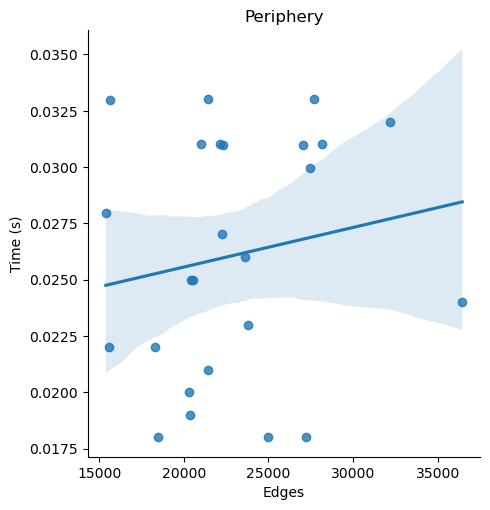

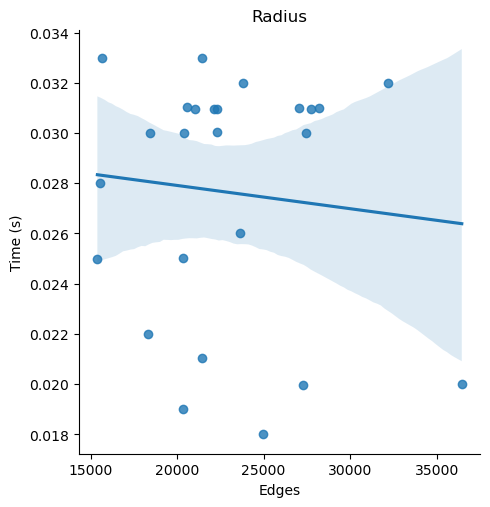

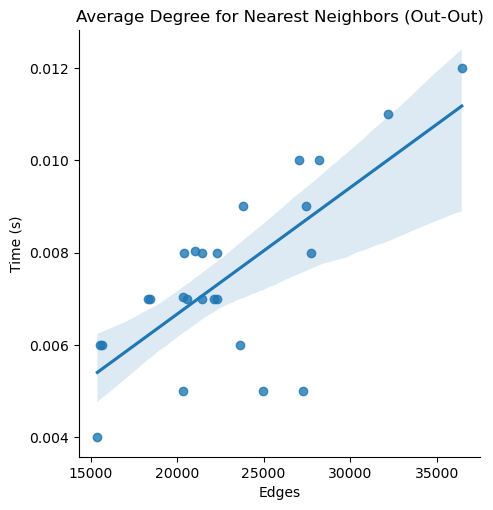

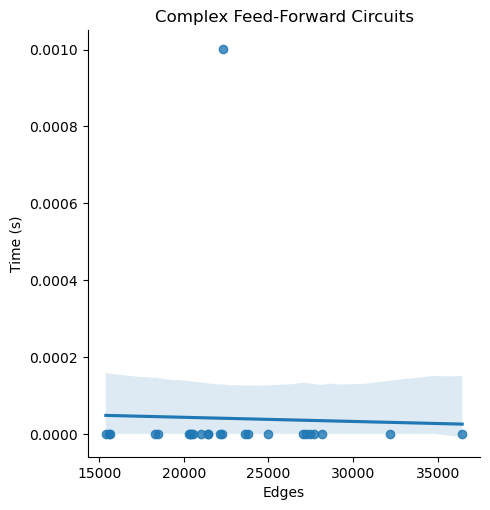

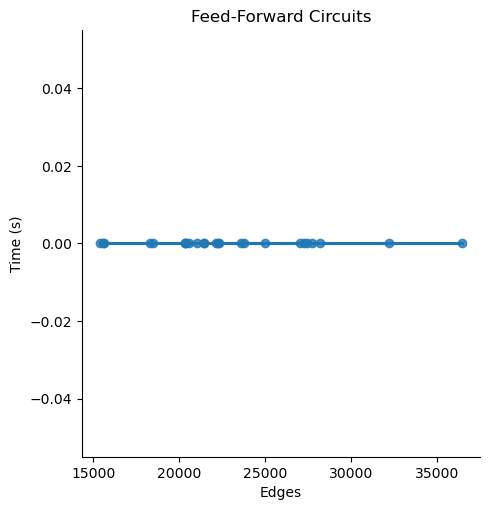

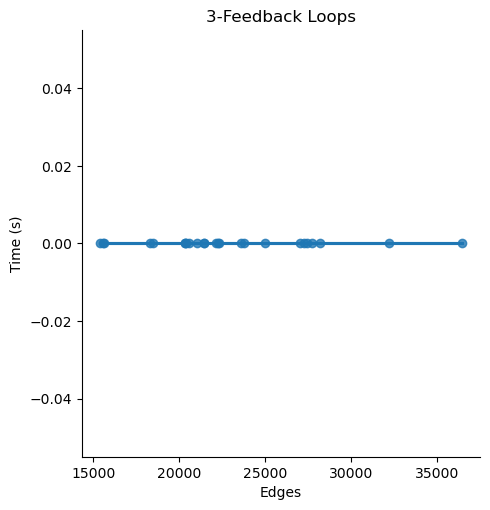

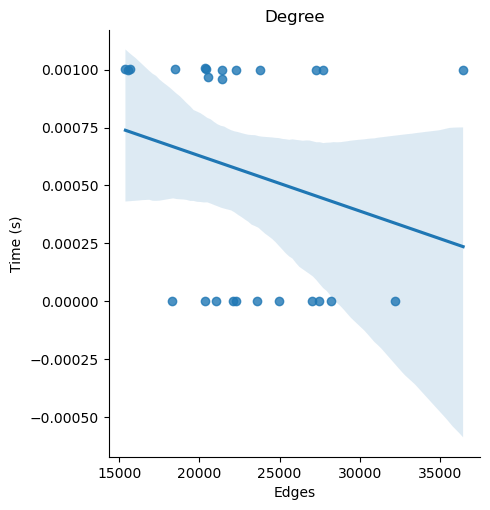

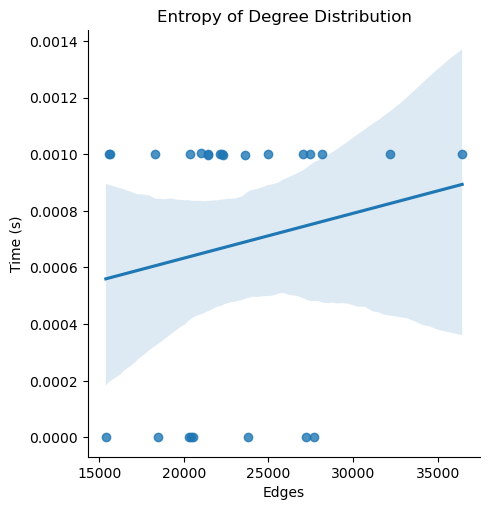

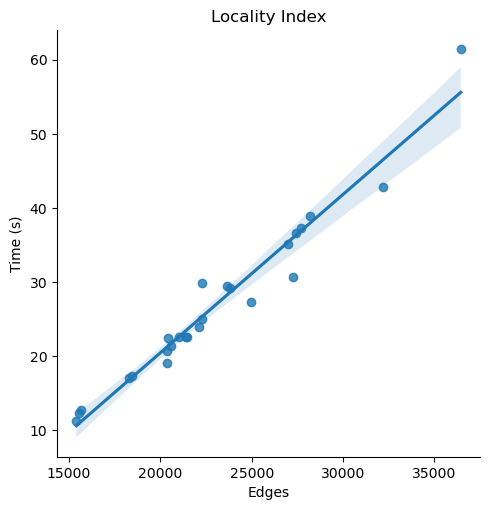

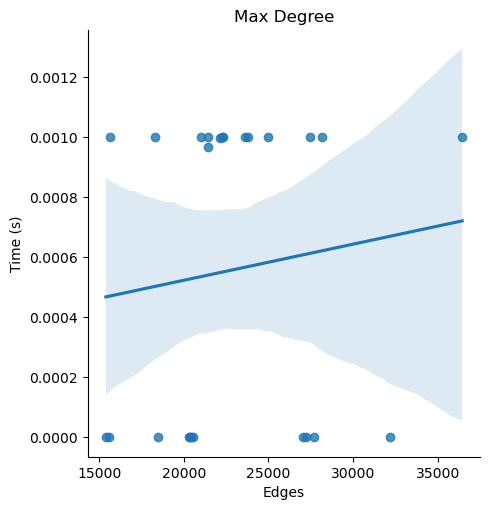

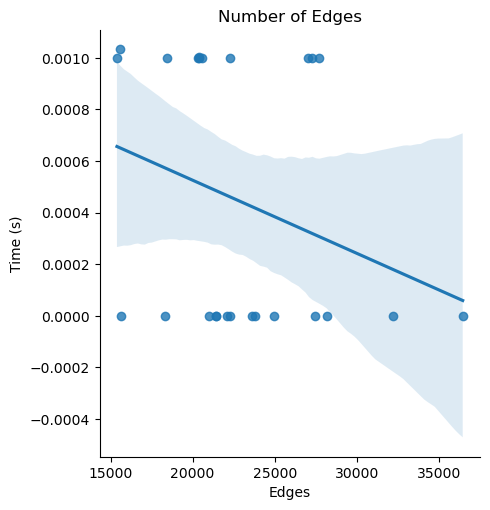

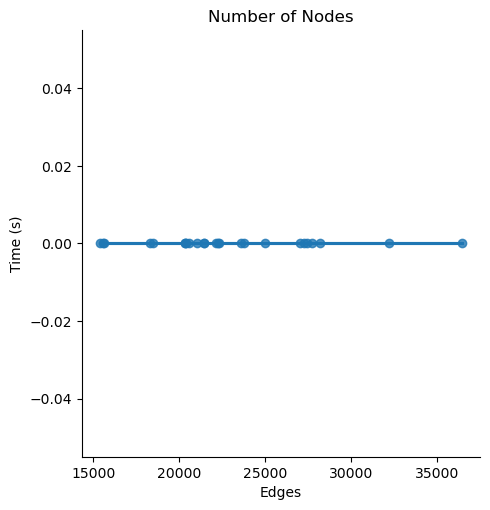

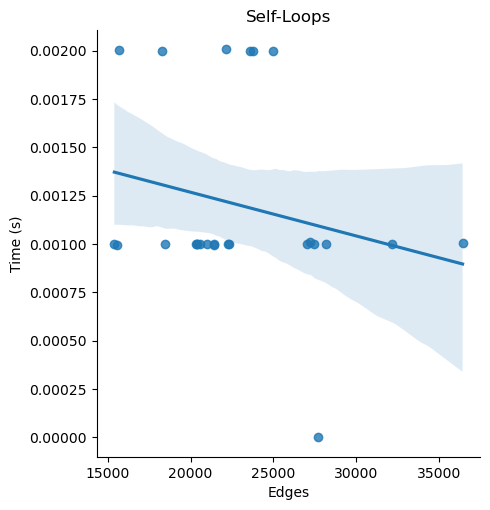

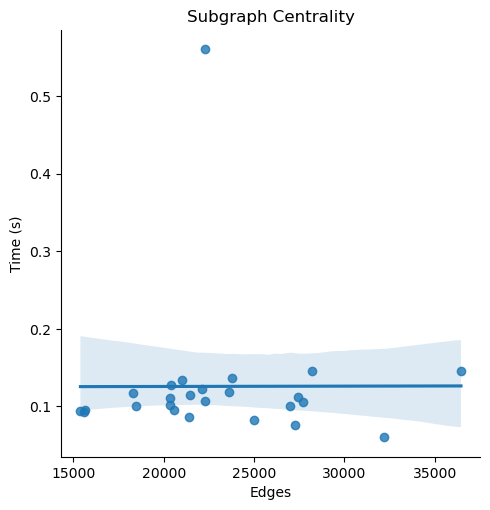

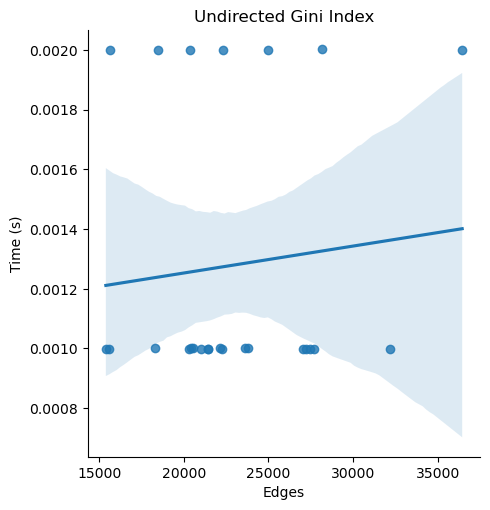

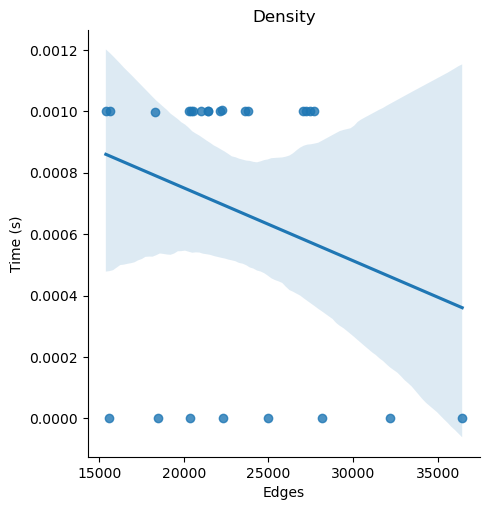

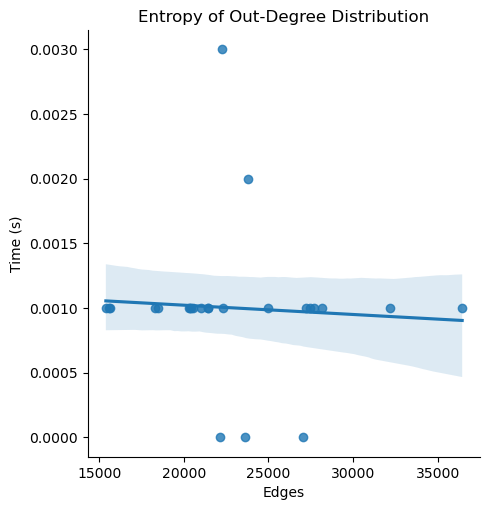

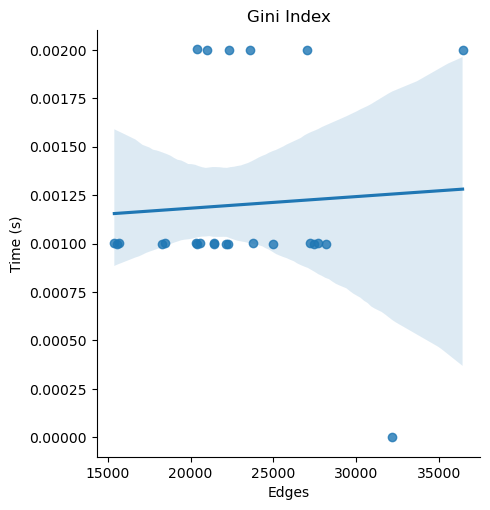

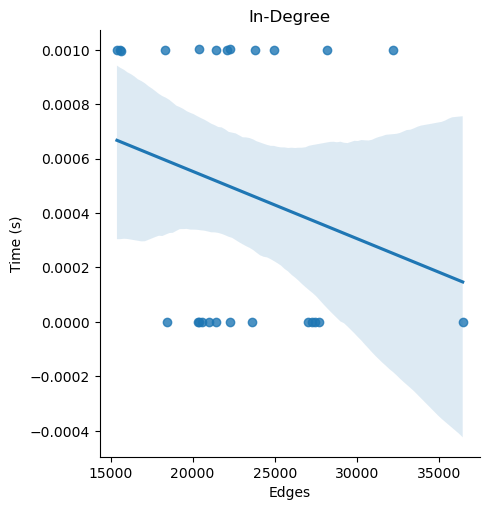

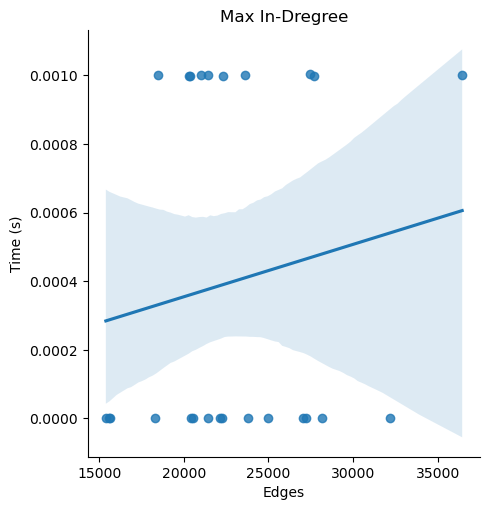

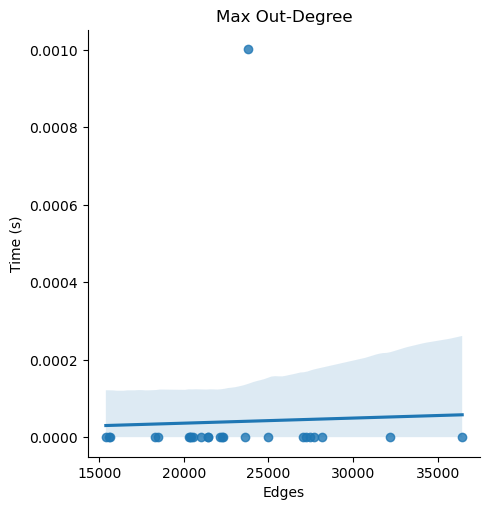

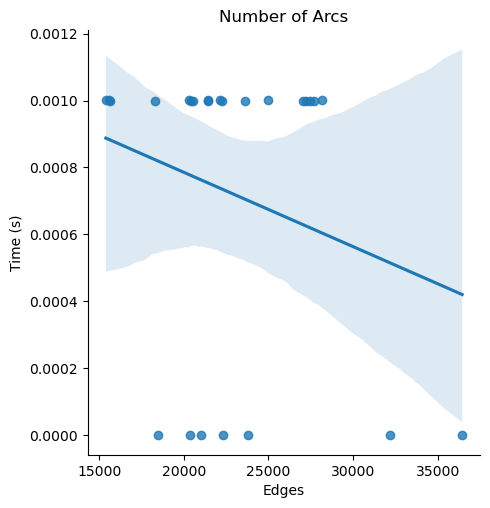

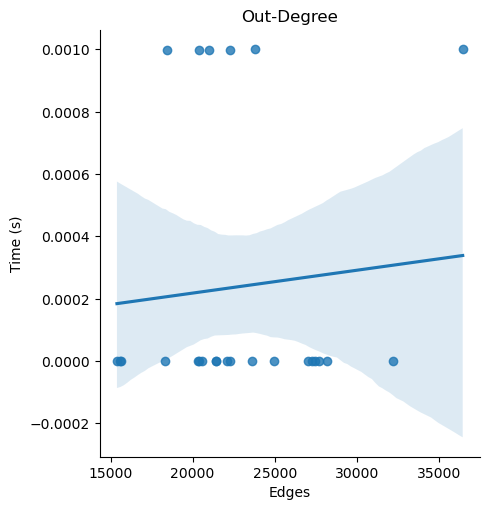

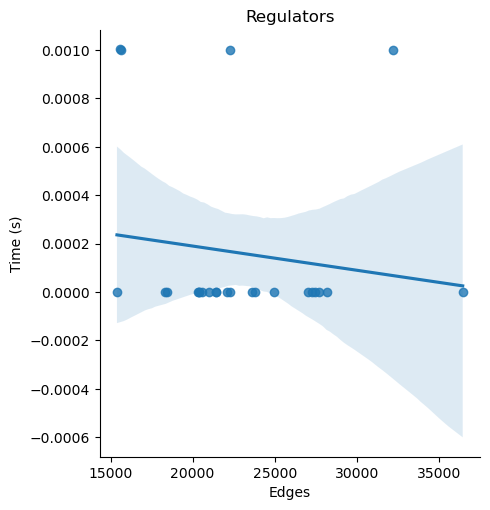

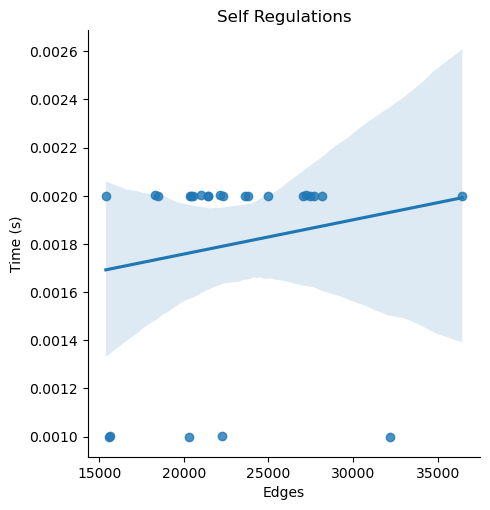

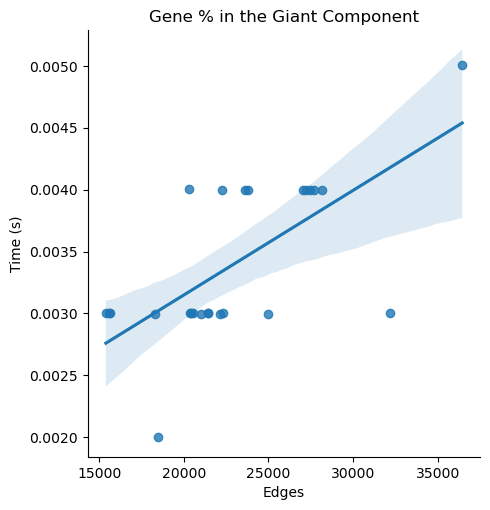

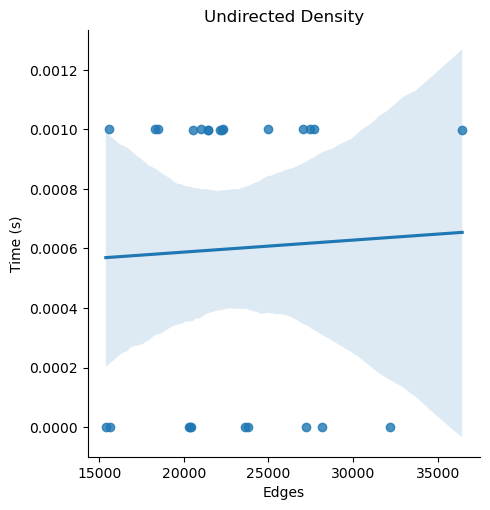

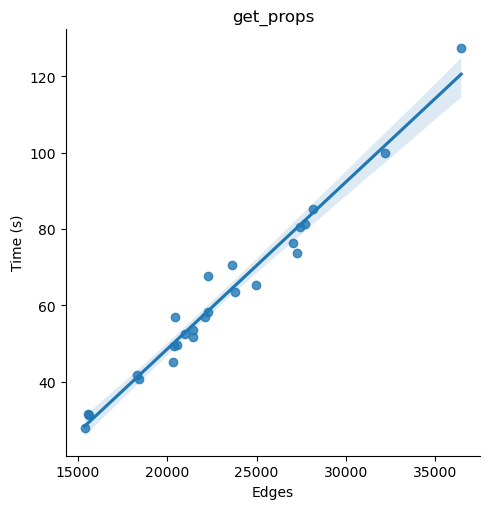

In [7]:
for prop, times in raw_times.items():
    if prop != 'edges' and prop != 'nodes':
        ax = sns.lmplot(
            data = raw_df,
            x = 'edges',
            y = prop, 
        )
        ax.set(
            xlabel='Edges',
            ylabel='Time (s)',
            title= prop
        )
        plt.show()